# Step 7: Visualization and Financial Analysis

## Objective
This step visualizes key analytical results produced in earlier stages.  
All data extraction and aggregation is performed using Spark, while Python plotting libraries are used only for rendering final results.


## 7.1 Environment Bootstrap (Windows) + Spark Initialization
This notebook reuses the same Spark + MongoDB integration as Step 6. On Windows, Spark requires `JAVA_HOME` and Hadoop `winutils.exe` via `HADOOP_HOME`. These variables are configured below for the current Jupyter kernel session.


In [1]:
import os
from dotenv import load_dotenv

# Load MongoDB URI from .env
load_dotenv()

# Windows Spark requirements
os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.17.10-hotspot"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

os.environ["HADOOP_HOME"] = r"C:\hadoop"
os.environ["hadoop.home.dir"] = r"C:\hadoop"
os.environ["PATH"] = r"C:\hadoop\bin;" + os.environ["PATH"]

MONGODB_URI = os.getenv("MONGODB_URI")
MONGODB_DB  = os.getenv("MONGODB_DB", "Stocks")

assert MONGODB_URI, "Missing MONGODB_URI in .env"

print("Bootstrap OK | DB:", MONGODB_DB)


Bootstrap OK | DB: Stocks


In [2]:
from pyspark.sql import SparkSession

MONGO_CONNECTOR = "org.mongodb.spark:mongo-spark-connector_2.12:10.3.0"

spark = (
    SparkSession.builder
    .appName("Step7_Visualization")
    .master("local[*]")
    .config("spark.jars.packages", MONGO_CONNECTOR)
    .config("spark.mongodb.read.connection.uri", MONGODB_URI)
    .config("spark.mongodb.write.connection.uri", MONGODB_URI)
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

print("Spark version:", spark.version)


Spark version: 3.5.3


## 7.8 Risk vs Return Analysis

This visualization compares annualized return against annualized volatility for each asset.  
The chart provides a high-level view of the risk–return trade-off across instruments and demonstrates how distributed analytics outputs (computed in Spark) can be used to generate interpretable financial insights.


In [3]:
from pyspark.sql import functions as F

risk_return_spark = (
    spark.read.format("mongodb")
    .option("database", MONGODB_DB)
    .option("collection", "spark_risk_return")
    .load()
    .select(
        "symbol",
        "annualized_return",
        "annualized_volatility",
        "sharpe_like"
    )
)

print("Rows:", risk_return_spark.count())

# Convert ONLY the final aggregated dataset (8 rows) for plotting
risk_pdf = risk_return_spark.toPandas()


Rows: 8


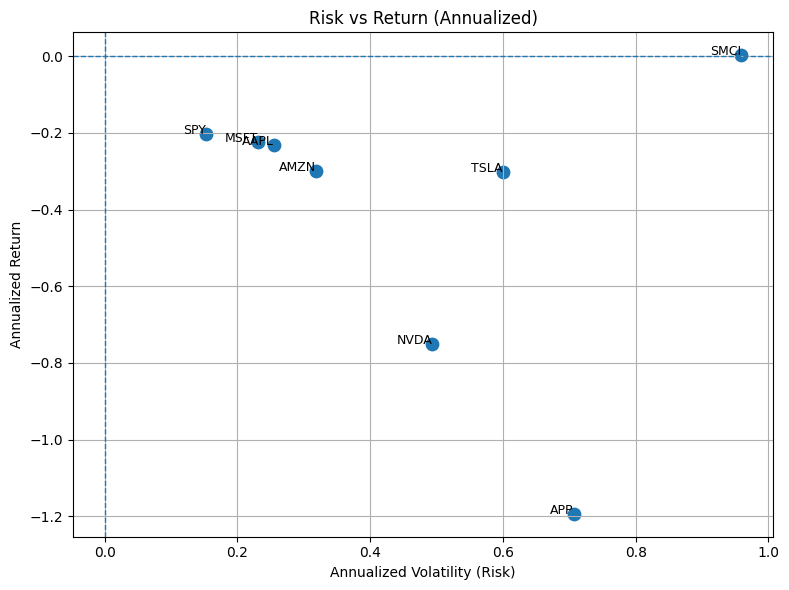

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    risk_pdf["annualized_volatility"],
    risk_pdf["annualized_return"],
    s=80
)

# Annotate points with symbol names
for _, row in risk_pdf.iterrows():
    plt.text(
        row["annualized_volatility"],
        row["annualized_return"],
        row["symbol"],
        fontsize=9,
        ha="right"
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.title("Risk vs Return (Annualized)")
plt.xlabel("Annualized Volatility (Risk)")
plt.ylabel("Annualized Return")
plt.grid(True)
plt.tight_layout()
plt.show()


## 7.4 Price and Moving Average Time-Series Visualization

This visualization shows the daily closing price along with 20-day and 50-day simple moving averages for a selected asset.  
All data preparation is performed using Spark, and pandas is used only for rendering the final plot.


In [5]:
from pyspark.sql import functions as F

# Select one symbol for visualization
SYMBOL = "AAPL"

price_sma_spark = (
    spark.read.format("mongodb")
    .option("database", MONGODB_DB)
    .option("collection", "daily_agg")
    .load()
    .filter(F.col("symbol") == SYMBOL)
    .select("timestamp", "close", "sma_20", "sma_50")
    .orderBy("timestamp")
)

print("Rows for plotting:", price_sma_spark.count())

# Convert ONLY the small, filtered result to pandas for plotting
price_sma_pdf = price_sma_spark.toPandas()


Rows for plotting: 752


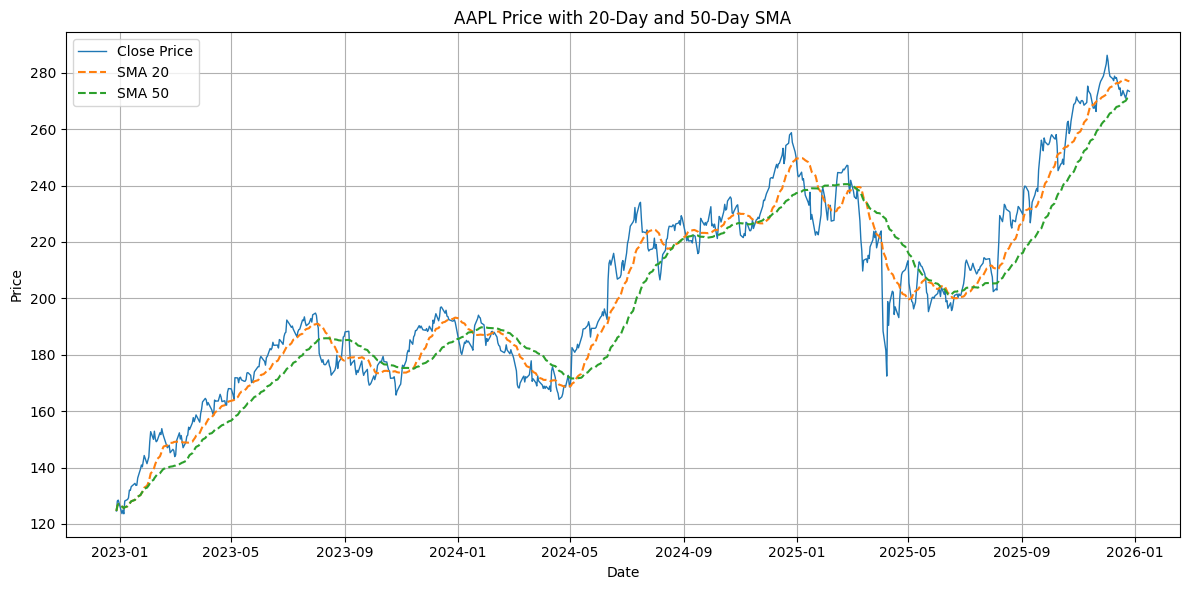

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(price_sma_pdf["timestamp"], price_sma_pdf["close"], label="Close Price", linewidth=1)
plt.plot(price_sma_pdf["timestamp"], price_sma_pdf["sma_20"], label="SMA 20", linestyle="--")
plt.plot(price_sma_pdf["timestamp"], price_sma_pdf["sma_50"], label="SMA 50", linestyle="--")

plt.title(f"{SYMBOL} Price with 20-Day and 50-Day SMA")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 7.5 Rolling Volatility (20-Day) Visualization
This plot visualizes the 20-day rolling volatility (`vol_20`) derived during feature engineering.  
Spark is used to load and filter the dataset; visualization is performed on the final result only.


Rows for plotting: 752


In [7]:
vol_spark = (
    spark.read.format("mongodb")
    .option("database", MONGODB_DB)
    .option("collection", "daily_agg")
    .load()
    .filter(F.col("symbol") == SYMBOL)
    .select("timestamp", "vol_20")
    .orderBy("timestamp")
)

print("Rows for plotting:", vol_spark.count())
vol_pdf = vol_spark.toPandas()


Rows for plotting: 752


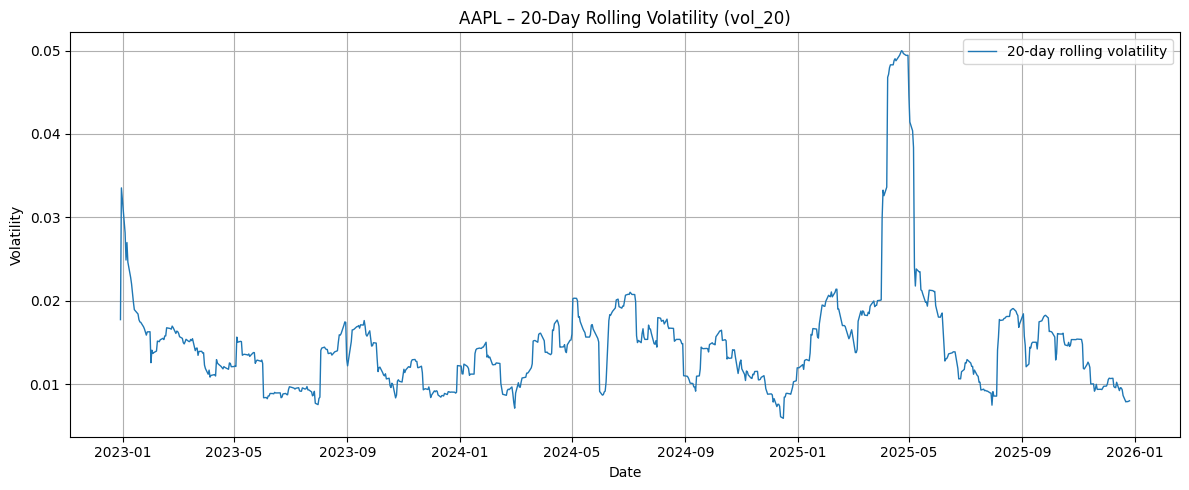

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(vol_pdf["timestamp"], vol_pdf["vol_20"], label="20-day rolling volatility", linewidth=1)
plt.title(f"{SYMBOL} – 20-Day Rolling Volatility (vol_20)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 7.6 RSI-14 Visualization
This plot shows the RSI-14 indicator computed in the feature engineering stage and stored persistently in MongoDB.  
RSI is useful for identifying overbought/oversold conditions (technical indicator demonstration).


In [9]:
rsi_spark = (
    spark.read.format("mongodb")
    .option("database", MONGODB_DB)
    .option("collection", "indicators")
    .load()
    .filter((F.col("symbol") == SYMBOL) & (F.col("interval") == "1day"))
    .select("timestamp", "rsi_14")
    .orderBy("timestamp")
)

print("Rows for plotting:", rsi_spark.count())
rsi_pdf = rsi_spark.toPandas()


Rows for plotting: 752


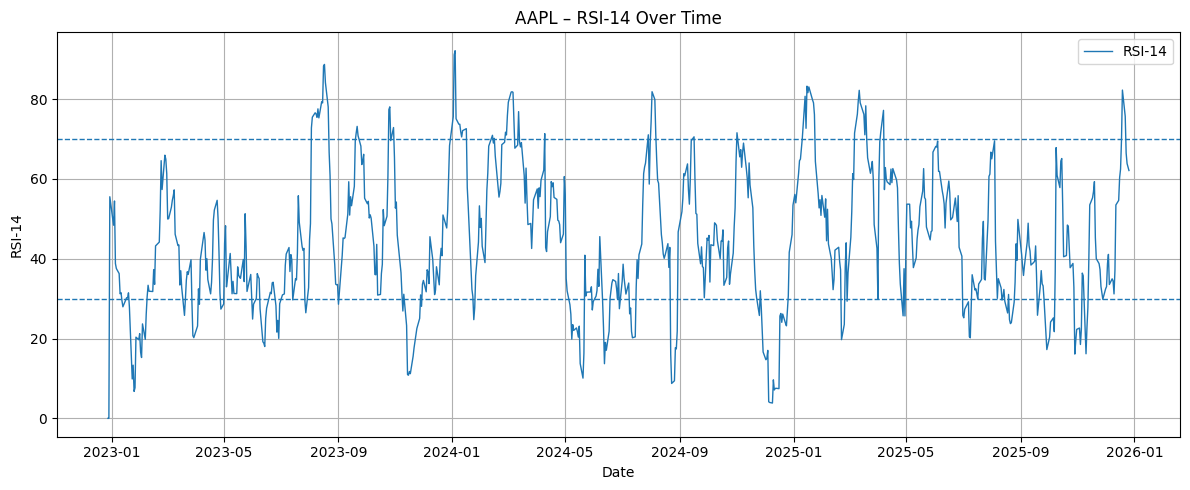

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(rsi_pdf["timestamp"], rsi_pdf["rsi_14"], label="RSI-14", linewidth=1)
plt.axhline(70, linestyle="--", linewidth=1)  # overbought threshold
plt.axhline(30, linestyle="--", linewidth=1)  # oversold threshold
plt.title(f"{SYMBOL} – RSI-14 Over Time")
plt.xlabel("Date")
plt.ylabel("RSI-14")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 7.7 Monthly Returns Visualization
This plot visualizes monthly returns computed in Spark (Step 6) and stored in MongoDB (`spark_monthly_returns`).  
It provides a compact view of performance across time at a monthly granularity.


In [10]:
monthly_spark = (
    spark.read.format("mongodb")
    .option("database", MONGODB_DB)
    .option("collection", "spark_monthly_returns")
    .load()
    .filter(F.col("symbol") == SYMBOL)
    .select("year_month", "monthly_return")
    .orderBy("year_month")
)

print("Rows for plotting:", monthly_spark.count())
monthly_pdf = monthly_spark.toPandas()


Rows for plotting: 37


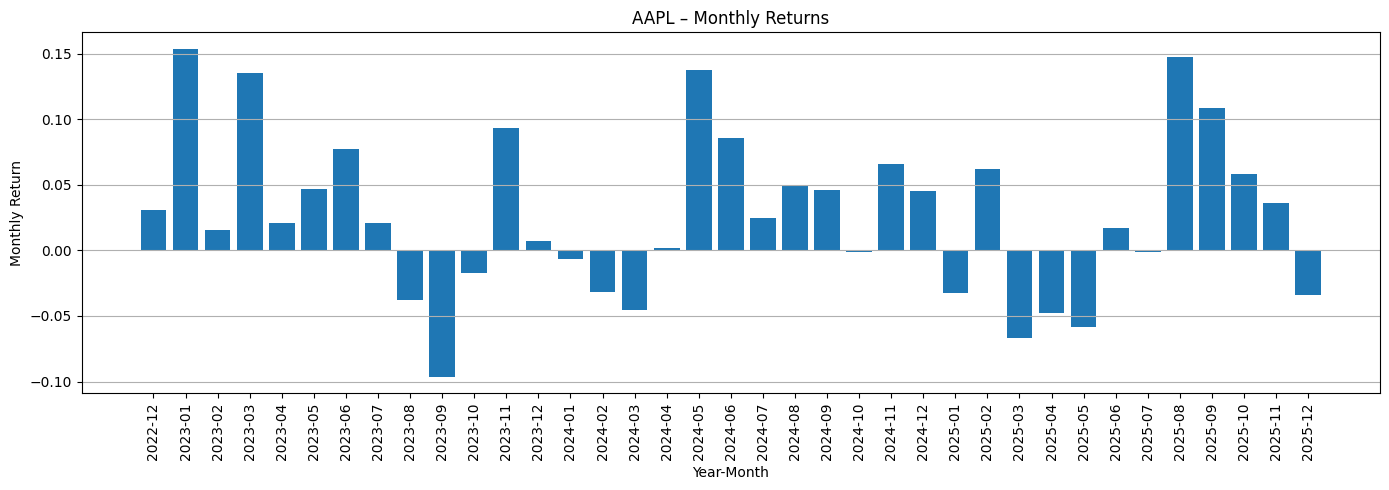

In [11]:
plt.figure(figsize=(14, 5))
plt.bar(monthly_pdf["year_month"], monthly_pdf["monthly_return"])
plt.title(f"{SYMBOL} – Monthly Returns")
plt.xlabel("Year-Month")
plt.ylabel("Monthly Return")
plt.xticks(rotation=90)
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()


## Conclusion (Step 7)

This project implemented an end-to-end Big Data financial analytics pipeline that combines persistent storage, multi-source ingestion, feature engineering, distributed processing, and visualization. Historical daily OHLCV data and periodic quote snapshots were persistently ingested into MongoDB Atlas, validated for integrity and consistency, and transformed into analytics-ready features (returns, moving averages, rolling volatility, and RSI).

Apache Spark (PySpark) was then used as a distributed processing engine to read persisted feature stores from MongoDB, perform joins and aggregations at scale, and persist results back into MongoDB as reusable analytical datasets (risk/return summary and monthly returns). Finally, Step 7 visualizations demonstrated how these persisted outputs can be used to generate interpretable market insights, including price trends relative to SMA indicators, volatility regimes, RSI dynamics, and monthly performance patterns.


## Limitations

- **Scale and compute environment:** Spark was executed in local mode on a single machine (Windows). While the pipeline demonstrates distributed concepts, true cluster execution (multi-node) was outside the scope of this proposed setup.
- **API constraints:** Alpha Vantage free-tier limits restrict high-frequency ingestion and intraday candle depth. Velocity ingestion was demonstrated through periodic quote snapshots rather than full intraday time-series bars.
- **Market coverage:** The asset universe is limited to eight U.S. instruments and ~3 years of daily data. This was sufficient for demonstrating pipeline design, but broader universes would strengthen statistical robustness.
- **Simplified risk metric:** The “Sharpe-like” metric is computed without a risk-free rate and without adjustments for trading days or market regimes; it is included primarily to demonstrate distributed aggregation, not as a production-grade risk model.
- **Veracity out of scope:** Data veracity, corporate actions (splits/dividends), and advanced cleaning were intentionally minimized, as per project scope and course focus.


## Future Work

- **True streaming ingestion:** Replace periodic polling with a streaming-capable ingestion layer (e.g., Kafka + Spark Structured Streaming) to demonstrate real streaming pipelines and windowed computations.
- **Cluster deployment:** Run Spark on a distributed cluster (e.g., Databricks, EMR, or standalone Spark cluster) to validate scalability beyond local mode.
- **Expanded dataset:** Extend to more symbols, longer history, and higher-frequency bars to better represent Volume and Velocity challenges and allow richer cross-asset analytics.
- **Additional analytics:** Add correlation/covariance matrices, drawdowns, rolling beta vs SPY, and regime detection, computed in Spark and persisted as feature tables.
- **Operationalization:** Add scheduling (e.g., cron/GitHub Actions), job logging, and automated validation checks to move toward production-style data engineering workflows.


## Step 7 Output Summary

The following persisted datasets were visualized in this step:
- `daily_agg` (MongoDB): close prices, SMA-20, SMA-50, rolling volatility
- `indicators` (MongoDB): RSI-14
- `spark_risk_return` (MongoDB): per-symbol risk/return summary computed in Spark
- `spark_monthly_returns` (MongoDB): monthly returns computed in Spark
